# 3.3 — DeiT-tiny fine-tuning completo — Food-101

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/marcoslund/ViT-for-101-food-app/blob/main/notebooks/3.3-deit.ipynb)

Entrenamiento completo de **DeiT-tiny** (`facebook/deit-tiny-patch16-224`) con la estructura del proyecto y los artefactos de `2.0-preprocessing.ipynb`.

DeiT (*Data-efficient image Transformer*) es un ViT entrenado con **destilacion** y augmentation fuerte para no depender de datasets gigantes. Usamos la variante **tiny**: un ViT puro a 224px, sin la jerarquia de Swin ni la parte convolucional de MobileViT.

- El **codigo de modelo y entrenamiento vive en `modeling/training.py`** y la orquestacion en `modeling/benchmark.py`; aca solo se llaman funciones.
- Reusa `config.py` y `preprocessing/loaders.py`: no se reimplementan resize, crop, normalizacion ni augmentation.
- La evaluacion usa `modeling/evaluation.py`, **el mismo codigo para todos los modelos del benchmark**.
- `test` se usa una sola vez al final; la pregunta del proyecto la contesta el **subset del benchmark por tercil**.
- Al terminar, guarda el mejor modelo y lo **descarga a tu computadora** (sección 8.1).
- Checkpoints bajo `models/deit/full/`; resultados livianos en `reports/results/deit/`.

**Variante:** deit-tiny (~5-6M params) es un ViT puro liviano, comparable en tamanio a MobileViT-small pero sin conv. Para mas precision, cambiar la linea `deit` de `config.MODELS` a `facebook/deit-small-patch16-224`. La notebook lee la resolucion del checkpoint y ajusta el batch sola.

> Para una corrida **desatendida** (Kaggle, VM), el mismo pipeline esta como CLI: `python -m vit_for_101_food_app.modeling.train --model deit`.

## 0. Antes de ejecutar

Desde la raiz del repo:

```bash
uv sync --extra deep
uv run jupyter lab
```

El preprocessing debe existir (`make preprocess` o `notebooks/2.0-preprocessing.ipynb`). En **Colab** no hace falta nada previo: sección 0.2 y sección 0.3 arman todo.

## 0.1 Parametros de ejecucion

- `USE_DRIVE` (solo Colab): guarda dataset, checkpoints y resultados en Google Drive. El disco de Colab se borra al desconectarse; sin Drive, una desconexion a mitad de entrenamiento pierde todo.
- `RESUME`: `True` retoma desde el ultimo checkpoint de `OUTPUT_DIR` (corrida cortada). Con `False` y checkpoints viejos, la notebook se detiene en vez de mezclarlos.
- `REPO_BRANCH`: rama que Colab clona. Con todo mergeado a `main`, dejar `"main"`.

In [1]:
# Solo Colab: persistir dataset, checkpoints y resultados en Google Drive.
USE_DRIVE = True
DRIVE_DIR = "/content/drive/MyDrive/ceia-vpc3"

# True = retomar desde el ultimo checkpoint de OUTPUT_DIR (corrida cortada).
RESUME = False

# Rama a clonar en Colab.
REPO_BRANCH = "main"


## 0.2 Entorno (Colab)

En Colab clona el repo (rama `REPO_BRANCH`) e instala el paquete con el extra `deep`. `torch` ya viene con CUDA en Colab. Localmente solo verifica que el paquete este instalado.

In [2]:
import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
print(f"Colab: {IN_COLAB}")


def _paquete_disponible():
    try:
        import vit_for_101_food_app  # noqa: F401

        return True
    except ImportError:
        return False


if IN_COLAB:
    REPO_URL = "https://github.com/marcoslund/ViT-for-101-food-app.git"
    REPO_DIR = "/content/ViT-for-101-food-app"
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "-q", "-b", REPO_BRANCH, REPO_URL, REPO_DIR], check=True)
    else:
        # Ya clonado: traer la ultima version de la rama. Si actualizo codigo del paquete,
        # despues hay que reiniciar el runtime para que se reimporte.
        subprocess.run(["git", "-C", REPO_DIR, "pull", "-q"], check=False)
    sys.path.insert(0, REPO_DIR)

    if not _paquete_disponible():
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "-e", f"{REPO_DIR}[deep]"], check=True
        )
    os.chdir(f"{REPO_DIR}/notebooks")

    if USE_DRIVE:
        from google.colab import drive

        drive.mount("/content/drive")
        os.makedirs(DRIVE_DIR, exist_ok=True)
elif not _paquete_disponible():
    raise RuntimeError(
        "vit_for_101_food_app no esta instalado en este kernel. "
        "Elegi el kernel del .venv del proyecto (ver 'Antes de ejecutar')."
    )

print("paquete disponible:", _paquete_disponible())


2026-09-26 09:41:28.457 | INFO     | vit_for_101_food_app.config:<module>:11 - PROJ_ROOT path is: C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app


Colab: False
paquete disponible: True


## 0.3 Datos (Colab)

Lo que localmente hace `make preprocess`: descarga (o copia de Drive) el dataset, genera el split deterministico si falta y arma el cache a `CACHE_SHORT_SIDE` (288). Localmente esta celda no hace nada.

Si venias de una corrida con el cache a otra resolucion, `prep.cache` lo detecta y lo regenera; tarda unos minutos una sola vez.

In [3]:
if IN_COLAB:
    import shutil

    from vit_for_101_food_app import config
    from vit_for_101_food_app import dataset as prep

    tar_local = config.RAW_DATA_DIR / "food-101.tar.gz"
    tar_drive = f"{DRIVE_DIR}/food-101.tar.gz"
    config.RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
    if USE_DRIVE and os.path.exists(tar_drive) and not tar_local.exists():
        print("copiando el dataset desde Drive...")
        shutil.copy(tar_drive, tar_local)

    prep.download()  # descarga (~5 GB) y extrae; idempotente
    if USE_DRIVE and not os.path.exists(tar_drive):
        print("guardando el dataset en Drive para la proxima sesion...")
        shutil.copy(tar_local, tar_drive)

    if not config.TRAIN_VAL_SPLIT.exists():
        prep.split()
    prep.cache(workers=os.cpu_count() or 2)  # cache a 288px; idempotente


In [4]:
from pathlib import Path
import sys

import pandas as pd
import torch

from vit_for_101_food_app import config, plots
from vit_for_101_food_app.modeling import benchmark, evaluation, training
from vit_for_101_food_app.preprocessing import loaders

MODEL_KEY = "deit"

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM: {props.total_memory / 1024**3:.1f} GB")
else:
    print("Dispositivo: CPU (el full training en CPU es lento; usa una GPU).")


c:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.11.16
PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM: 8.0 GB


## 1. Verificar artefactos de preprocessing

In [5]:
id2label, label2id = benchmark.verify_artifacts()
NUM_LABELS = len(label2id)

print("cache:", config.CACHE_DIR, "| lado corto:", config.CACHE_SHORT_SIDE)
print("clases:", NUM_LABELS)


cache: C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\data\interim\food-101-288 | lado corto: 288
clases: 101


## 2. DataLoaders de DeiT-tiny

`loaders.build_dataloaders("deit", ...)` lee del `AutoImageProcessor` de DeiT la resolucion (224), la normalizacion (ImageNet) y el resample; no se escribe ningun numero a mano.

El batch lo elige `training.resolve_batch_plan` segun la resolucion del checkpoint y la GPU: modelos livianos a 224/256px entran con batch 32; un checkpoint de alta resolucion (>=320px) baja el batch, activa acumulacion de gradiente para mantener el batch efectivo en 32, y prende gradient checkpointing. Misma heuristica para todos.

In [6]:
plan = training.resolve_batch_plan(MODEL_KEY)
print(
    "resolucion:", plan.target_size,
    "| batch:", plan.batch_size, "x", plan.grad_accum, "=", plan.effective_batch,
    "| gradient checkpointing:", plan.gradient_checkpointing,
)

dls = loaders.build_dataloaders(
    MODEL_KEY,
    train_policy="standard",
    source="cache",
    batch_size=plan.batch_size,
    num_workers=plan.num_workers,
    splits_to_load=("train", "val", "test"),
)

train_ds = dls["train"].dataset
val_ds = dls["val"].dataset
test_ds = dls["test"].dataset

print("train:", len(train_ds), "| val:", len(val_ds), "| test:", len(test_ds))
assert len(train_ds) == 68175
assert len(val_ds) == 7575
assert len(test_ds) == 25250

batch = next(iter(dls["train"]))
print("pixel_values:", tuple(batch["pixel_values"].shape), batch["pixel_values"].dtype)


resolucion: 224 | batch: 16 x 2 = 32 | gradient checkpointing: False
train: 68175 | val: 7575 | test: 25250
pixel_values: (16, 3, 224, 224) torch.float32


## 3. DeiT-tiny preentrenado

In [7]:
CHECKPOINT = config.MODELS[MODEL_KEY]
print("checkpoint:", CHECKPOINT)

model = training.build_model(MODEL_KEY, id2label, label2id)

params = training.count_parameters(model)
print(f"parametros totales: {params['total'] / 1e6:.2f} M")
print(f"parametros entrenables: {params['trainable'] / 1e6:.2f} M")


checkpoint: facebook/deit-tiny-patch16-224


[transformers] You passed `num_labels=101` which is incompatible to the `id2label` map of length `1000`.
c:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\.venv\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Antonella\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-devic

parametros totales: 5.54 M
parametros entrenables: 5.54 M


## 4. Configuracion del fine-tuning

Misma receta para todos los modelos del benchmark (`TrainingRecipe` en `training.py`): hasta 20 epocas con early stopping (paciencia 3), mejor checkpoint por **F1 macro** en validation, warmup lineal del 5 %, `lr = 5e-4`, seed 42. El gradient checkpointing y la acumulacion de gradiente se activan solos segun la resolucion (sección 2).

In [8]:
recipe = training.TrainingRecipe(batch_size=plan.batch_size, grad_accum_steps=plan.grad_accum)

OUTPUT_DIR, RESULTS_DIR = benchmark.default_dirs(MODEL_KEY)
if IN_COLAB and USE_DRIVE:
    OUTPUT_DIR = Path(DRIVE_DIR) / "models" / MODEL_KEY / "full"
    RESULTS_DIR = Path(DRIVE_DIR) / "results" / MODEL_KEY
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

training.guard_output_dir(OUTPUT_DIR, RESUME)

print("output:", OUTPUT_DIR)
print("resultados:", RESULTS_DIR)
print(training.recipe_as_dict(recipe))


output: C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\models\deit\full
resultados: C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\reports\results\deit
{'epochs': 20, 'learning_rate': 0.0005, 'weight_decay': 0.01, 'warmup_ratio': 0.05, 'batch_size': 16, 'grad_accum_steps': 2, 'early_stopping_patience': 3, 'metric_for_best': 'f1_macro', 'seed': 42}


## 5. Trainer

In [9]:
trainer = training.build_trainer(
    model,
    recipe,
    output_dir=OUTPUT_DIR,
    train_dataset=train_ds,
    val_dataset=val_ds,
    num_workers=plan.num_workers,
    gradient_checkpointing=plan.gradient_checkpointing,
)


## 6. Fine-tuning completo

In [10]:
elapsed_train = training.run_training(trainer, resume=RESUME)
print(f"tiempo total: {elapsed_train / 3600:.2f} h")
print("best F1 macro:", trainer.state.best_metric)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,2.100556,2.115419,0.461914,0.462962
2,1.741738,1.734580,0.549571,0.553358
3,1.492076,1.627187,0.575182,0.581471
4,1.322616,1.393948,0.633267,0.632146
5,1.191425,1.416144,0.634455,0.641036
6,1.037878,1.289358,0.662310,0.663078
7,0.909902,1.279712,0.666931,0.665699
8,0.792397,1.263502,0.678944,0.679838
9,0.682215,1.285114,0.684752,0.688430
10,0.545611,1.306208,0.686469,0.685146


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 46.49it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 

2026-09-26 10:44:36.749 | SUCCESS  | vit_for_101_food_app.modeling.training:run_training:232 - entrenamiento: 62.3 min | best 0.7204 en C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\models\deit\full\checkpoint-40489
tiempo total: 1.04 h
best F1 macro: 0.7204269820704454


## 7. Historial por epoca

In [11]:
training.epoch_history(trainer)


,epoch,eval_loss,eval_accuracy,eval_f1_macro
0,1.0,2.115419,0.461914,0.462962
1,2.0,1.734580,0.549571,0.553358
2,3.0,1.627187,0.575182,0.581471
3,4.0,1.393948,0.633267,0.632146
4,5.0,1.416144,0.634455,0.641036
5,6.0,1.289358,0.662310,0.663078
6,7.0,1.279712,0.666931,0.665699
7,8.0,1.263502,0.678944,0.679838
8,9.0,1.285114,0.684752,0.688430
9,10.0,1.306208,0.686469,0.685146


2026-09-26 10:44:37.091 | SUCCESS  | vit_for_101_food_app.plots:plot_training_curves:180 - curvas guardadas en C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\reports\results\deit (curvas-deit-*.png)


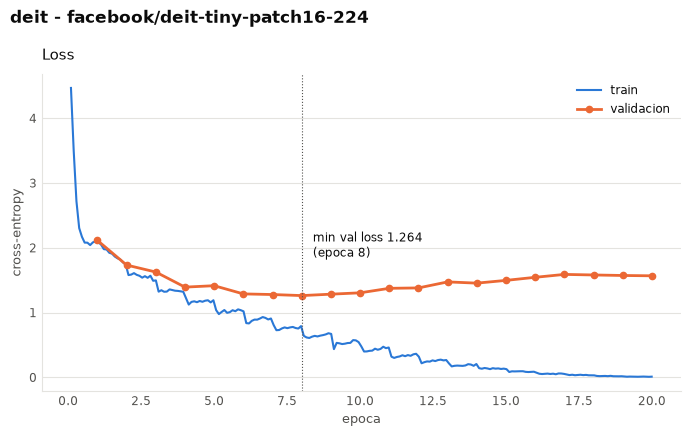

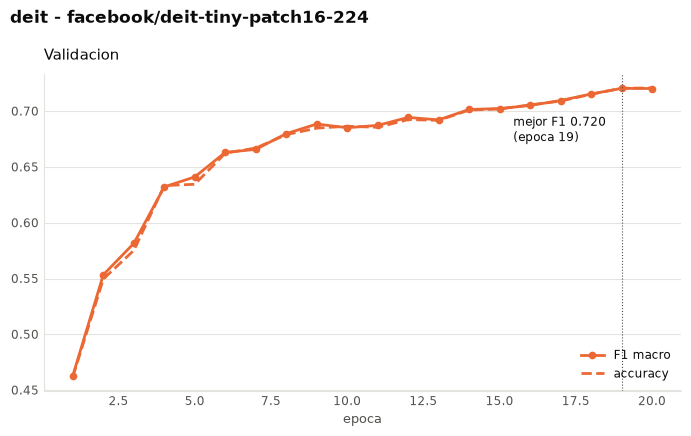

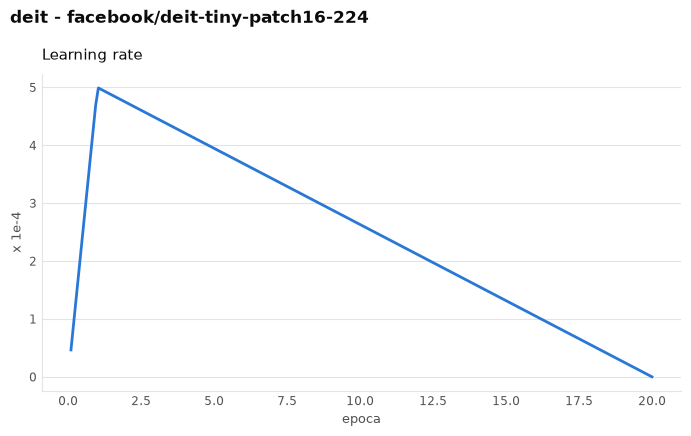

In [12]:
log_history = trainer.state.log_history
plots.history_table(log_history).to_csv(RESULTS_DIR / "training_history.csv", index=False)
rutas = plots.plot_training_curves(
    log_history,
    f"{MODEL_KEY} - {config.MODELS[MODEL_KEY]}",
    RESULTS_DIR,
    prefix=f"curvas-{MODEL_KEY}",
)


## 8. Guardar el mejor modelo

In [13]:
BEST_DIR = training.save_best_model(trainer, OUTPUT_DIR)


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 58.83it/s]

2026-09-26 10:44:37.338 | SUCCESS  | vit_for_101_food_app.modeling.training:save_best_model:243 - mejor modelo guardado en C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\models\deit\full\best


## 8.1 Descargar el modelo a tu computadora

Comprime el mejor modelo y, en Colab, lo descarga al navegador. El `.zip` trae los pesos (`model.safetensors`) y la config, listos para `AutoModelForImageClassification.from_pretrained(carpeta_descomprimida)` (o para el CLI `python -m vit_for_101_food_app.modeling.predict`).

Si la descarga del navegador falla, con `USE_DRIVE = True` el modelo ya quedo en tu Drive (`OUTPUT_DIR/best`).

In [14]:
zip_path = training.zip_model(
    BEST_DIR,
    Path("/content") / f"{MODEL_KEY}-best" if IN_COLAB else OUTPUT_DIR / f"{MODEL_KEY}-best",
)
training.download_to_browser(zip_path)


2026-09-26 10:44:38.198 | SUCCESS  | vit_for_101_food_app.modeling.training:zip_model:251 - modelo comprimido en C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\models\deit\full\deit-best.zip
2026-09-26 10:44:38.199 | INFO     | vit_for_101_food_app.modeling.training:download_to_browser:262 - no es Colab: el archivo quedo en C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\models\deit\full\deit-best.zip


## 9. Evaluacion final sobre test

`test` se usa recien aca, una sola vez. Las predicciones se guardan **por imagen** (`predictions_test.csv`): con eso se recalcula cualquier metrica y se compara contra los otros modelos sin reentrenar.

In [15]:
test_preds, test_metrics, elapsed_test = evaluation.evaluate_test(trainer, test_ds, id2label)
test_preds.to_csv(RESULTS_DIR / "predictions_test.csv", index=False)

print(f"tiempo test: {elapsed_test:.1f} s")
pd.Series(test_metrics)


tiempo test: 49.4 s


n                25250.000000
n_clases           101.000000
accuracy             0.776752
top5_accuracy        0.931446
f1_macro             0.776511
dtype: float64

## 10. Subset del benchmark por tercil de dificultad

La tabla que contesta la pregunta del proyecto. El subset es **el mismo archivo para todos los modelos** y `load_benchmark_subset` verifica su `sha256` antes de usarlo.

In [16]:
subset = evaluation.load_benchmark_subset()
benchmark_tabla = evaluation.benchmark_metrics(test_preds, subset)
benchmark_tabla.to_csv(RESULTS_DIR / "benchmark_por_tercil.csv")
benchmark_tabla


,n,n_clases,accuracy,top5_accuracy,f1_macro
grupo,,,,,
subset,2525,101,0.788119,0.940990,0.787719
facil,850,34,0.877647,0.970588,0.916845
medio,825,33,0.781818,0.945455,0.836274
dificil,850,34,0.704706,0.907059,0.757438


## 11. Reporte por clase

In [17]:
report_df = evaluation.per_class_report(test_preds, id2label)
report_df.to_csv(RESULTS_DIR / "report_por_clase_test.csv")

print("10 clases con peor F1")
display(report_df.head(10))
print("10 clases con mejor F1")
display(report_df.tail(10))


10 clases con peor F1


,precision,recall,f1-score,support
steak,0.451852,0.488,0.469231,250.0
pork_chop,0.529915,0.496,0.512397,250.0
apple_pie,0.588496,0.532,0.558824,250.0
filet_mignon,0.540146,0.592,0.564885,250.0
ravioli,0.582031,0.596,0.588933,250.0
chocolate_mousse,0.550336,0.656,0.598540,250.0
bread_pudding,0.623377,0.576,0.598753,250.0
foie_gras,0.628205,0.588,0.607438,250.0
breakfast_burrito,0.663793,0.616,0.639004,250.0
huevos_rancheros,0.628352,0.656,0.641879,250.0


10 clases con mejor F1


,precision,recall,f1-score,support
seaweed_salad,0.889328,0.900,0.894632,250.0
bibimbap,0.874525,0.920,0.896686,250.0
spaghetti_carbonara,0.886719,0.908,0.897233,250.0
oysters,0.896414,0.900,0.898204,250.0
deviled_eggs,0.898438,0.920,0.909091,250.0
macarons,0.944681,0.888,0.915464,250.0
pho,0.906615,0.932,0.919132,250.0
miso_soup,0.930612,0.912,0.921212,250.0
hot_and_sour_soup,0.953390,0.900,0.925926,250.0
edamame,0.980237,0.992,0.986083,250.0


## 12. Confusiones mas frecuentes

In [18]:
confusiones = evaluation.frequent_confusions(test_preds)
confusiones.to_csv(RESULTS_DIR / "confusiones_test.csv", index=False)
print("errores totales:", int((~test_preds["correct"]).sum()), "de", len(test_preds))
confusiones.head(15)


errores totales: 5637 de 25250


,class_dir,pred_class,n
0,steak,filet_mignon,46
1,filet_mignon,steak,46
2,chocolate_cake,chocolate_mousse,33
3,tuna_tartare,beef_tartare,28
4,pork_chop,steak,26
5,chocolate_mousse,chocolate_cake,25
6,prime_rib,steak,22
7,ravioli,gnocchi,22
8,beef_tartare,tuna_tartare,21
9,steak,prime_rib,21


## 13. Costo arquitectonico: parametros, FLOPs, tamanio y latencia

Se mide con `modeling/evaluation.py`, el mismo codigo para todos los modelos: esa es la condicion para comparar arquitecturas.

- **Tamanio de los pesos** por precision: fp32 (lo que se entrena) y las cotas fp16/int8, que es lo que ocuparia el modelo cuantizado al enviarlo a un dispositivo.
- **Latencia** con batch 1 (una foto por vez), mediana y p90 de 100 corridas, en GPU y CPU.
- **Medicion del lado del dispositivo**: el modelo cuantizado a int8 (dinamica sobre capas `Linear`) medido en CPU — tamanio real serializado y latencia. Es lo que sostiene el eje "recursos acotados" mas alla de FLOPs/params en la GPU de entrenamiento.

In [19]:
sample = test_ds[0]["pixel_values"].unsqueeze(0)
costo, latencia = evaluation.architectural_cost(model, sample, trainer.args.device)

print(pd.Series(costo))

# Latencia fp32 en GPU (si hay) y CPU
lat_fp32 = {k: v for k, v in latencia.items() if k in ("gpu", "cpu") and v is not None}
display(pd.DataFrame(lat_fp32))

# Medicion del lado del dispositivo: modelo cuantizado a int8 medido en CPU
print("\nCPU int8 (cuantizado):")
print(pd.Series(latencia["cpu_int8"]))


W0926 10:45:27.828000 22632 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


params_m         5.543909
size_mb_fp32    21.148335
size_mb_fp16    10.574167
size_mb_int8     5.287084
gflops           2.507021
gmacs            1.253511
dtype: float64


,gpu,cpu
device,NVIDIA GeForce RTX 5060 Laptop GPU,cpu
batch_size,1,1
cpu_threads,1,1
n_runs,100,100
median_ms,6.45465,50.38475
p90_ms,7.64527,52.85411
mean_ms,6.66229,43.900173



CPU int8 (cuantizado):
soportado                            True
dtype                               qint8
capas_cuantizadas    nn.Linear (dinamica)
size_mb                          6.023143
median_ms                        19.03695
p90_ms                           25.04002
mean_ms                         20.373836
n_runs                                 50
dtype: object


## 14. Guardar metricas

In [20]:
metrics = benchmark.assemble_metrics(
    MODEL_KEY, recipe, trainer, elapsed_train, test_metrics, benchmark_tabla, costo, latencia
)
destino = benchmark.save_metrics(metrics, RESULTS_DIR)
print("guardado en", destino)
for p in sorted(RESULTS_DIR.iterdir()):
    print(" -", p.name)


guardado en C:\Users\Antonella\Documents\Facultad\Maestría en IA\VC III\Repo proyecto integrador\ViT-for-101-food-app\reports\results\deit\metrics.json
 - benchmark_por_tercil.csv
 - confusiones_test.csv
 - curvas-deit-loss.png
 - curvas-deit-lr.png
 - curvas-deit-validacion.png
 - metrics.json
 - predictions_test.csv
 - report_por_clase_test.csv
 - training_history.csv


## Resumen

- Todo el codigo de modelo/entrenamiento vive en `vit_for_101_food_app/modeling/` (`training.py`, `evaluation.py`, `benchmark.py`); esta notebook solo orquesta.
- `train` para entrenar, `val` para early stopping y seleccion de checkpoint, `test` una sola vez.
- La metrica que contesta la pregunta del proyecto es la del **subset por tercil** (sección 10).
- El mejor modelo queda en `models/deit/full/best/` y se descarga a tu compu (sección 8.1); **no** se versiona.

Con los `metrics.json` de cada modelo (mismo esquema para todos) se arma la tabla comparativa del benchmark sin reentrenar.

**En Colab** con `USE_DRIVE = True`, los resultados quedan en `ceia-vpc3/results/deit/` de tu Drive: para versionarlos, copialos a `reports/results/deit/` del checkout local.